In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patheffects as pe
from SharedX import ShareXaxis
from UniversalColor import UniversalColor
from legend_shadow import legend_shadow
from scipy.io import readsav
import spiceypy as spice
import time

import JupiterMag as jm

import os

UC = UniversalColor()
UC.set_palette()

F = ShareXaxis()
F.fontsize = 23
F.fontname = 'Liberation Sans Narrow'
F.set_default()

Importing Library
done


In [2]:
# 定数
RJ = 71492*1E+3  # Jupiter radius [m]
RE = 1560*1E+3   # Europa radius [m]
# Angular velocity of Jupiter System III rotation [rad sec-1]
OMG_J = 2*np.pi/(9.55*3600)
OMG_G = 2*np.pi/(7.2*24*3600)   # Ganymede orbital angular velosity [rad/sec]

Psyn_eu = (11.22)*3600      # Moon's synodic period [sec]
Psyn_ga = (10.53)*3600      # Moon's synodic period [sec]

Tracing field line 2 of 2 (100.00)%
Tracing field line 2 of 2 (100.00)%
Tracing field line 2 of 2 (100.00)%
[0.38268343 0.57357644] [0. 0.] [-0.92387953 -0.81915204]


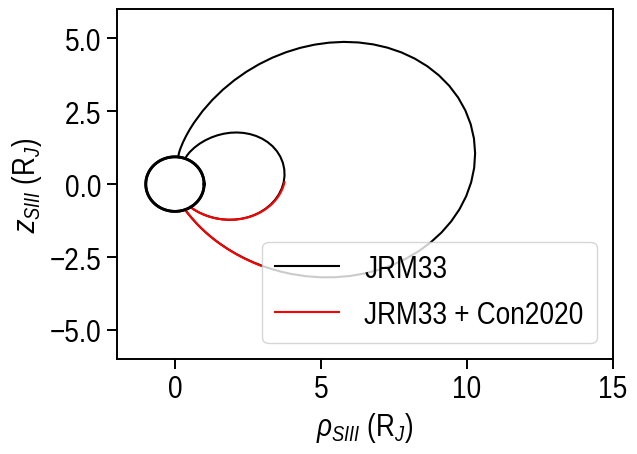

In [3]:
# Jupiter magnetic field model initialization
jm.Internal.Config(Model='jrm33', CartesianIn=True, CartesianOut=True)
jm.Con2020.Config(equation_type='hybrid')

# create some starting positions
n = 2
theta = (180.0 - np.linspace(22.5, 35, n))*np.pi/180.0
r = np.ones(n)
x0 = r*np.sin(theta)
y0 = np.zeros(n)
z0 = r*np.cos(theta)

# create trace objects, pass starting position(s) x0,y0,z0
T0 = jm.TraceField(x0, y0, z0, Verbose=True, IntModel='jrm33', ExtModel='none')
T1 = jm.TraceField(x0, y0, z0, Verbose=True, IntModel='jrm33', ExtModel='Con2020',
                   MaxLen=300,
                   ErrMax=0.00000001)
T2 = jm.TraceField(x0, y0, z0, Verbose=True, IntModel='jrm33',
                   ExtModel='Con2020', MaxLen=2000)

# plot a trace
ax = T0.PlotRhoZ(label='JRM33', color='black')
ax = T1.PlotRhoZ(fig=ax, label='JRM33 + Con2020', color='red')
# ax = T2.PlotRhoZ(fig=ax,label='JRM33 + Con2020',color='blue')

ax.set_xlim(-2.0, 15.0)
ax.set_ylim(-6.0, 6.0)

print(x0, y0, z0)

In [4]:
jm.Internal.Config(Model='jrm33', Degree=13,
                   CartesianIn=True, CartesianOut=True)
jm.Con2020.Config(equation_type='hybrid')

# Manual trace
r0 = 15.0                   # [RJ]
theta0 = np.radians(90.0)   # [rad]
phi0 = np.radians(270.0)      # [rad]

x0 = r0*np.sin(theta0)*np.cos(phi0)
y0 = r0*np.sin(theta0)*np.sin(phi0)
z0 = r0*np.cos(theta0)

Niter = int(600000)

ds = 100000.0     # [m]

ns = -1

start = time.time()
x, y, z = x0, y0, z0
for i in range(Niter):
    # Community codes
    Bx0, By0, Bz0 = jm.Internal.Field(x, y, z)  # [nT]
    Bx1, By1, Bz1 = jm.Con2020.Field(x, y, z)   # [nT]
    Bx = (Bx0+Bx1)*1E-9     # [T]
    By = (By0+By1)*1E-9     # [T]
    Bz = (Bz0+Bz1)*1E-9     # [T]

    B0 = math.sqrt(Bx[0]**2+By[0]**2+Bz[0]**2)      # [T]

    # 座標更新 (x, y, z)
    x += (ds*Bx[0]/B0)*ns/RJ
    y += (ds*By[0]/B0)*ns/RJ
    z += (ds*Bz[0]/B0)*ns/RJ

    # 座標更新 (r, theta, phi)
    rs = math.sqrt(x**2 + y**2 + z**2)      # [RJ]
    theta = math.acos(z/rs)
    phi = math.atan2(y, x)

    # thetaで基準
    if rs < 1.0:
        print('Trace finished.')
        print(rs, 90.0-math.degrees(theta), 360.0-math.degrees(phi))
        print('Time [s]:', round(time.time()-start, 2))
        break

Trace finished.
0.9989777915632081 61.76336337494645 501.2980741107176
Time [s]: 53.83


In [5]:
jm.Internal.Config(Model='jrm33', Degree=18,
                   CartesianIn=True, CartesianOut=True)
jm.Con2020.Config(equation_type='integral')

x0 = r0*np.sin(theta0)*np.cos(phi0)
y0 = r0*np.sin(theta0)*np.sin(phi0)
z0 = r0*np.cos(theta0)

Niter = int(600000)

ds = 100000.0     # [m]

ns = -1

start = time.time()
x, y, z = x0, y0, z0
for i in range(Niter):
    # Community codes
    Bx0, By0, Bz0 = jm.Internal.Field(x, y, z)  # [nT]
    Bx1, By1, Bz1 = jm.Con2020.Field(x, y, z)   # [nT]
    Bx = (Bx0+Bx1)*1E-9     # [T]
    By = (By0+By1)*1E-9     # [T]
    Bz = (Bz0+Bz1)*1E-9     # [T]

    B0 = math.sqrt(Bx[0]**2+By[0]**2+Bz[0]**2)      # [T]

    # 座標更新 (x, y, z)
    x += (ds*Bx[0]/B0)*ns/RJ
    y += (ds*By[0]/B0)*ns/RJ
    z += (ds*Bz[0]/B0)*ns/RJ

    # 座標更新 (r, theta, phi)
    rs = math.sqrt(x**2 + y**2 + z**2)      # [RJ]
    theta = math.acos(z/rs)
    phi = math.atan2(y, x)

    # thetaで基準
    if rs < 1.0:
        print('Trace finished.')
        print(rs, 90.0-math.degrees(theta), 360.0-math.degrees(phi))
        print('Time [s]:', round(time.time()-start, 2))
        break

Trace finished.
0.9997340199487488 61.5922165472773 501.414676068055
Time [s]: 827.69


In [6]:
jm.Internal.Config(Model='jrm33', Degree=13,
                   CartesianIn=True, CartesianOut=True)
jm.Con2020.Config(equation_type='analytic')

# Manual trace
x0 = r0*np.sin(theta0)*np.cos(phi0)
y0 = r0*np.sin(theta0)*np.sin(phi0)
z0 = r0*np.cos(theta0)

Niter = int(600000)

ds = 50000.0     # [m]

ns = -1

x, y, z = x0, y0, z0
start = time.time()
for i in range(Niter):
    # Community codes
    Bx0, By0, Bz0 = jm.Internal.Field(x, y, z)  # [nT]
    Bx1, By1, Bz1 = jm.Con2020.Field(x, y, z)   # [nT]
    Bx = (Bx0+Bx1)*1E-9     # [T]
    By = (By0+By1)*1E-9     # [T]
    Bz = (Bz0+Bz1)*1E-9     # [T]

    B0 = math.sqrt(Bx[0]**2+By[0]**2+Bz[0]**2)      # [T]

    # 座標更新 (x, y, z)
    x += (ds*Bx[0]/B0)*ns/RJ
    y += (ds*By[0]/B0)*ns/RJ
    z += (ds*Bz[0]/B0)*ns/RJ

    # 座標更新 (r, theta, phi)
    rs = math.sqrt(x**2 + y**2 + z**2)      # [RJ]
    theta = math.acos(z/rs)
    phi = math.atan2(y, x)

    # thetaで基準
    if rs < 1.0:
        print('Trace finished.')
        print(rs, 90.0-math.degrees(theta),
              np.mod(360.0-math.degrees(phi), 360.0))
        print('Time [s]:', round(time.time()-start, 2))
        break

Trace finished.
0.9998119964613447 61.75879379849826 141.21956087198623
Time [s]: 1.95


In [7]:
jm.Internal.Config(Model='jrm33', Degree=18,
                   CartesianIn=True, CartesianOut=True)
jm.Con2020.Config(equation_type='analytic')

# Manual trace
x0 = r0*np.sin(theta0)*np.cos(phi0)
y0 = r0*np.sin(theta0)*np.sin(phi0)
z0 = r0*np.cos(theta0)

Niter = int(600000)

ds = 50000.0     # [m]

ns = -1

x, y, z = x0, y0, z0
start = time.time()
for i in range(Niter):
    # Community codes
    Bx0, By0, Bz0 = jm.Internal.Field(x, y, z)  # [nT]
    Bx1, By1, Bz1 = jm.Con2020.Field(x, y, z)   # [nT]
    Bx = (Bx0+Bx1)*1E-9     # [T]
    By = (By0+By1)*1E-9     # [T]
    Bz = (Bz0+Bz1)*1E-9     # [T]

    B0 = math.sqrt(Bx[0]**2+By[0]**2+Bz[0]**2)      # [T]

    # 座標更新 (x, y, z)
    x += (ds*Bx[0]/B0)*ns/RJ
    y += (ds*By[0]/B0)*ns/RJ
    z += (ds*Bz[0]/B0)*ns/RJ

    # 座標更新 (r, theta, phi)
    rs = math.sqrt(x**2 + y**2 + z**2)      # [RJ]
    theta = math.acos(z/rs)
    phi = math.atan2(y, x)

    # thetaで基準
    if rs < 1.0:
        print('Trace finished.')
        print(rs, 90.0-math.degrees(theta),
              np.mod(360.0-math.degrees(phi), 360.0))
        print('Time [s]:', round(time.time()-start, 2))
        break

Trace finished.
0.9996884152352902 61.56777028899119 141.3651849597809
Time [s]: 1.99


Trace finished.
Time [s]: 0.86
60.15543830370493 -143.86097088511747
59.92155012298641 -144.0478088145376


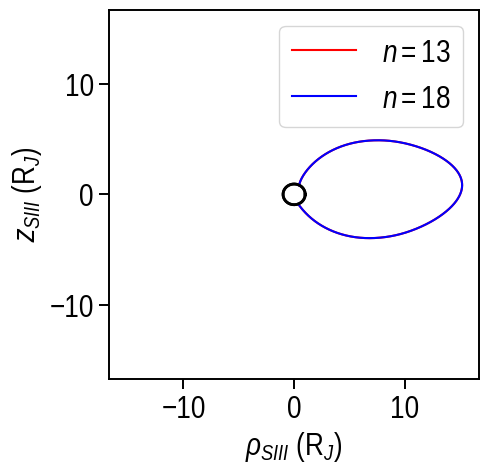

In [8]:
jm.Internal.Config(Model='jrm33', Degree=13,
                   CartesianIn=True, CartesianOut=True)
jm.Con2020.Config(equation_type='analytic')

T1 = jm.TraceField(x0, y0, z0,
                   IntModel='jrm33', ExtModel='Con2020',
                   MaxStep=0.0003,
                   MaxLen=800000, ErrMax=0.000001)

jm.Internal.Config(Model='jrm33', Degree=18,
                   CartesianIn=True, CartesianOut=True)
jm.Con2020.Config(equation_type='analytic')

start = time.time()
T2 = jm.TraceField(x0, y0, z0,
                   IntModel='jrm33', ExtModel='Con2020',
                   MaxStep=0.0003,
                   MaxLen=900000, ErrMax=0.00001)
print('Trace finished.')
print('Time [s]:', round(time.time()-start, 2))

# plot a trace
ax = T1.PlotRhoZ(label=r'$n=13$', color='red')
ax = T2.PlotRhoZ(fig=ax, label=r'$n=18$', color='blue')

print(T1.ionosphere.latn[0], T1.ionosphere.lonn[0])
print(T2.ionosphere.latn[0], T2.ionosphere.lonn[0])